### Installation
Run the following command to install the required database drivers and data processing libraries:

In [1]:
!pip install psycopg2-binary
!pip install sqlalchemy psycopg2-binary pandas
!pip install tabulate

### Core Dependencies
The following Python modules are required to establish the database connection, suppress non-critical SQLAlchemy version warnings, and handle data frame manipulations.

In [2]:
import psycopg2
import pandas as pd
from sqlalchemy import create_engine, text
import warnings

warnings.filterwarnings("ignore")

### Infrastructure Management
To ensure a successful audit, this section performs a verification of the port:
**Port Check:** Uses `socket` to verify that the local tunnel (Port 5433) is open and listening.

In [3]:
import socket

def check_port(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', int(port))) == 0

for p in ['5432', '5433']:
    if check_port(p):
        print(f"Port {p} is OPEN and listening!")
    else:
        print(f"Port {p} is CLOSED.")

Port 5432 is CLOSED.
Port 5433 is OPEN and listening!


### Database Connection Setup
The audit requires a stable connection to the PostgreSQL production database. This block establishes the connection engine using SQLAlchemy and validates the connection by querying the current database name.

**Note:** Ensure the SSH/SSM tunnel is active on port 5433 before executing.

In [4]:
# 1. Use actual credentials here
user_name = 'frida_takubetang'      # Default is usually 'postgres'
password = 'SUL241zzRnI9qIg7z'  # The password you set during installation
host = 'localhost'          # 'localhost' if the DB is on your computer
port = '5433'               # Default PostgreSQL port
db_name = 'layereddb'       # The name of the database you created

# 2. Create the connection string (URL)
connection_url = f"postgresql://{user_name}:{password}@{host}:{port}/{db_name}"

# 3. Create the Engine
engine = create_engine(connection_url)

# 4. Test the connection
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT current_database();"))
        db_now = result.fetchone()[0]
        print(f"Successfully connected to: {db_now}")
except Exception as e:
    print(f"Connection failed. Check the username/password.\nError: {e}")

Successfully connected to: layereddb


### Schema Discovery
To ensure the audit targets the correct environment, first inspect the database to list all available schemas. The primary focus for this task is the `berlin_source_data` schema, which contains the raw Point of Interest (POI) layers.

In [5]:
from sqlalchemy import inspect

# Create an inspector object
inspector = inspect(engine)

# Get all schema names
schemas = inspector.get_schema_names()

print("Available Schemas in layereddb:")
for schema in schemas:
    print(f"- {schema}")

Available Schemas in layereddb:
- berlin_labels
- berlin_mini_dashboard
- berlin_recommender
- berlin_source_data
- berlin_statistics
- berlin_unified_data
- dashboard_data
- information_schema
- public
- staging


### Targeted Column Inventory: berlin_source_data
This block performs a deep-scan of the `berlin_source_data` schema. It maps every column and data type across all POI tables, providing the foundation for the automated compliance check.

### Setup and Target Selection

In [6]:
from IPython.display import display

# Initialize the inspector 
inspector = inspect(engine)

# Target the specific schema for the POI audit
target_schema = 'berlin_source_data'
db_inventory = []

print(f"Starting inventory scan for schema: '{target_schema}'...")

Starting inventory scan for schema: 'berlin_source_data'...


### Table Discovery & Filtering

In [8]:
# Get all table names in the schema
all_tables = inspector.get_table_names(schema=target_schema)

# DEFINITION: These are Polygon/Area layers.
# They correctly lack lat/lon points and should be audited differently or excluded.
reference_layers = ['districts', 'neighborhoods']

# FILTER:
# 1. Remove 'stat' (statistics) tables
# 2. Remove 'reference_layers' (Polygon areas) to focus only on Point POIs
poi_tables = [
    t for t in all_tables
    if 'stat' not in t.lower() and t not in reference_layers
]

# Show the total pool for clarity
print(f"Total tables found in schema: {len(all_tables)}") 
print(f"Reference Layers Excluded: {reference_layers}")
print(f"Audit Target: {len(poi_tables)} Point-based POI tables identified.")

Total tables found in schema: 44
Reference Layers Excluded: ['districts', 'neighborhoods']
Audit Target: 41 Point-based POI tables identified.


### Metadata Extraction

In [8]:
# Loop through the POI tables to extract column-level metadata
for table in poi_tables:
    try:
        columns = inspector.get_columns(table, schema=target_schema)
        for col in columns:
            db_inventory.append({
                "Table": table,
                "Column": col['name'],
                "Type": str(col['type']),
                "Nullable": col.get('nullable'),
                "Primary Key": col.get('primary_key') == 1
            })
    except Exception as e:
        print(f"Warning: Could not read table '{table}': {e}")

### Inventory Visualization

In [9]:
# Convert the list of dictionaries into a clean DataFrame
df_inventory = pd.DataFrame(db_inventory)

if not df_inventory.empty:
    print(f"Total POI columns mapped: {len(df_inventory)}")
    display(df_inventory.head(20)) # Display first 20 rows 
else:
    print("Inventory is empty. Please verify the database connection.")

Total POI columns mapped: 756


,Table,Column,Type,Nullable,Primary Key
0,tram_stops,id,VARCHAR,False,False
1,tram_stops,district_id,VARCHAR,False,False
2,tram_stops,name,VARCHAR,False,False
3,tram_stops,latitude,"NUMERIC(9, 6)",False,False
4,tram_stops,longitude,"NUMERIC(9, 6)",False,False
5,tram_stops,shelter,VARCHAR(50),True,False
6,tram_stops,geometry,NULL,False,False
7,tram_stops,neighborhood,VARCHAR,True,False
8,tram_stops,district,VARCHAR,True,False
9,tram_stops,neighborhood_id,VARCHAR,False,False


### Define project's requirements: Mandatory Standards

In [10]:
# Define the mandatory schema standards from the Task Brief
# These rules apply to all POI tables in berlin_source_data
MANDATORY_SCHEMA = {
    'id': 'VARCHAR',
    'district_id': 'VARCHAR',
    'name': 'VARCHAR',
    'latitude': ['NUMERIC', 'DECIMAL', 'DOUBLE'], # Accept any of these
    'longitude': ['NUMERIC', 'DECIMAL', 'DOUBLE'],
    'geometry': ['VARCHAR', 'NULL', 'GEOMETRY'], # Accepts the current NULL state found
    'neighborhood': 'VARCHAR',
    'district': 'VARCHAR',
    'neighborhood_id': 'VARCHAR'
}

print("Mandatory schema rules defined. Ready to compare against database inventory.")

Mandatory schema rules defined. Ready to compare against database inventory.


### Comparison and Error Flagging

In [11]:
compliance_report = []

for table in poi_tables:
    # Filter inventory for the current table
    table_data = df_inventory[df_inventory['Table'] == table]
    
    # FIX: Use .str.upper() to handle the Pandas Series correctly
    # Also use .fillna('') to prevent errors if a type is missing
    actual_cols = dict(zip(table_data['Column'], table_data['Type'].str.upper().fillna('')))
    
    missing = []
    type_mismatches = [] 
    
    for req_col, req_types in MANDATORY_SCHEMA.items():
        if req_col not in actual_cols:
            missing.append(req_col)
        else:
            actual_type = actual_cols[req_col]
            # Handle list of allowed types (e.g., ['NUMERIC', 'DECIMAL'])
            if isinstance(req_types, list):
                if not any(t in actual_type for t in req_types):
                    type_mismatches.append(f"{req_col}({actual_type})")
            else:
                if req_types not in actual_type:
                    type_mismatches.append(f"{req_col}({actual_type})")

    compliance_report.append({
        "Table Name": table,
        "Compliant": "YES" if not missing and not type_mismatches else "NO",
        "Missing Columns": ", ".join(missing) if missing else "None",
        "Incorrect Data Types": ", ".join(type_mismatches) if type_mismatches else "None"
    })

### The Audit Summary

In [12]:
# Convert the audit results into a summary DataFrame
df_report = pd.DataFrame(compliance_report)

# Display the summary
print(f"Audit Complete: {len(df_report)} POI Tables Scanned")
display(df_report)

# Export as Markdown for the 'schema_compliance_summary.md' file
print("\nCOPY THIS TO THE MARKDOWN SUMMARY:")
print("-" * 40)
print(df_report.to_markdown(index=False))

Audit Complete: 41 POI Tables Scanned


,Table Name,Compliant,Missing Columns,Incorrect Data Types
0,tram_stops,YES,None,None
1,bus_stops,YES,None,None
2,long_term_listings,NO,None,geometry(TEXT)
3,recycling_points,YES,None,None
4,veterinary_clinics,YES,None,None
5,schools_maximilian_burkhardt,NO,geometry,None
6,public_artworks,YES,None,None
7,spaetis,NO,"id, neighborhood, district",geometry(TEXT)
8,galleries,YES,None,None
9,kindergartens,YES,None,None



COPY THIS TO THE MARKDOWN SUMMARY:
----------------------------------------
| Table Name                    | Compliant   | Missing Columns            | Incorrect Data Types   |
|:------------------------------|:------------|:---------------------------|:-----------------------|
| tram_stops                    | YES         | None                       | None                   |
| bus_stops                     | YES         | None                       | None                   |
| long_term_listings            | NO          | None                       | geometry(TEXT)         |
| recycling_points              | YES         | None                       | None                   |
| veterinary_clinics            | YES         | None                       | None                   |
| schools_maximilian_burkhardt  | NO          | geometry                   | None                   |
| public_artworks               | YES         | None                       | None                   |
| spa

## Identification of Issues

### Based on the automated audit of 41 tables in berlin_source_data, the following critical issues were identified:

 ### 1. Structural Deficiencies (Missing Columns)
These issues prevent the affected layers from being integrated into the unified dashboard or joined with other Berlin datasets.

Critical Schema Gaps (spaetis): Missing mandatory identity and LOR (Lebensweltlich orientierte Räume) columns, specifically id, neighborhood, and district.

Impact: This layer cannot currently be indexed or aggregated by administrative area.

Spatial Asset Loss (spaetis, petstores): The geometry column is entirely absent.

Impact: These locations cannot be projected onto a map until coordinate-to-geometry conversion is performed.

Reference Layer Variance: neighborhoods and districts were flagged for missing latitude/longitude columns.

Context: This is technically "Expected Behavior" for Polygon layers.

Action: These layers will be exempted from the final Point-of-Interest (POI) unification view to maintain audit accuracy.

 ### 2. Geometric Compatibility (Type Mismatches)
Several tables contain spatial data that is improperly formatted for PostGIS or standard mapping engines.

Affected Tables: long_term_listings, spaetis, social_clubs_activities.

Issue: The geometry column is currently stored as a TEXT string rather than a spatial object.

Required Remediation: Data must be cast to formal PostGIS Geometry types (or the project-standard VARCHAR if used for transit storage).

Impact: Without this fix, the mapping engine cannot perform spatial queries (e.g., "Find all Spätis within 500m of this subway station").

## Compliance Table Visualization

In [13]:
!pip install jinja2

In [14]:
def style_compliance_accessible(val):
    # Using Blue (#0072B2) for YES and Orange (#D55E00) for NO
    if val == 'YES' or val == 'YES':
        return 'background-color: #0072B2; color: white; font-weight: bold;' 
    elif val == 'NO' or val == 'NO':
        return 'background-color: #D55E00; color: white; font-weight: bold;'
    return ''

# Apply 
styled_report = df_report.style.applymap(style_compliance_accessible, subset=['Compliant'])

# Display the styled table
styled_report

,Table Name,Compliant,Missing Columns,Incorrect Data Types
0,tram_stops,YES,None,None
1,bus_stops,YES,None,None
2,long_term_listings,NO,None,geometry(TEXT)
3,recycling_points,YES,None,None
4,veterinary_clinics,YES,None,None
5,schools_maximilian_burkhardt,NO,geometry,None
6,public_artworks,YES,None,None
7,spaetis,NO,"id, neighborhood, district",geometry(TEXT)
8,galleries,YES,None,None
9,kindergartens,YES,None,None


In [17]:
!pip install dataframe_image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 12.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 12.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 12.9 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32/32 [dataframe_image] [nbconvert]]


In [22]:
import dataframe_image as dfi

# 1. Apply accessible styling
styled_report = df_report.style.map(style_compliance_accessible, subset=['Compliant'])

# 2. Export using the Matplotlib engine to bypass Playwright
dfi.export(
    styled_report, 
    'compliance_table.png', 
    table_conversion='matplotlib'
)

print("SUCCESS: The 'matplotlib' engine bypassed the browser error.")

SUCCESS: The 'matplotlib' engine bypassed the browser error.


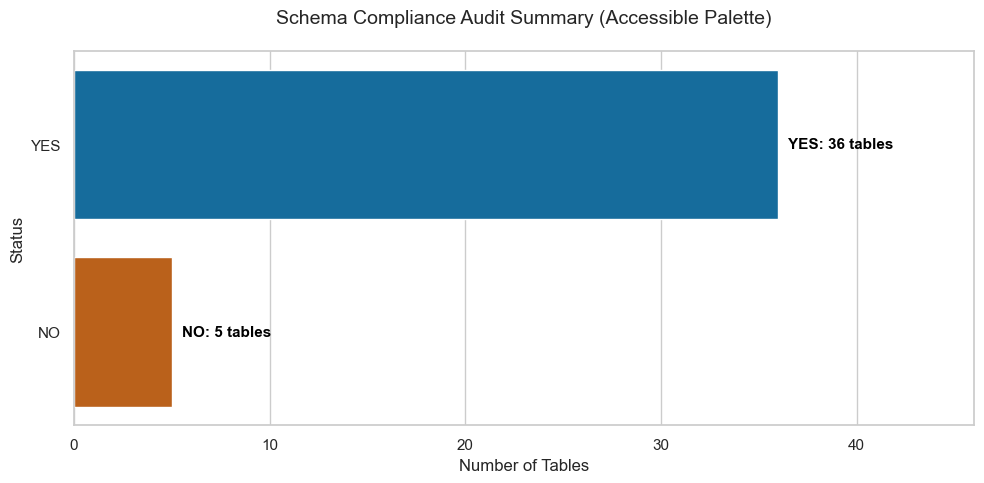

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the status
status_counts = df_report['Compliant'].value_counts()

# Define accessible colors (IBM/Wong Palette)
# Blue for YES, Orange for NO
color_map = {
    'YES': '#0072B2',
    'YES': '#0072B2',
    'NO': '#D55E00',
    'NO': '#D55E00'
}

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Create the bars
colors = [color_map.get(x, '#999999') for x in status_counts.index]
ax = sns.barplot(x=status_counts.values, y=status_counts.index, palette=colors)

# Add clear text labels to avoid relying only on color
for i, v in enumerate(status_counts.values):
    status_label = status_counts.index[i]
    ax.text(v + 0.5, i, f"{status_label}: {v} tables", 
            color='black', fontweight='bold', va='center', fontsize=11)

plt.title('Schema Compliance Audit Summary (Accessible Palette)', fontsize=14, pad=20)
plt.xlabel('Number of Tables', fontsize=12)
plt.ylabel('Status', fontsize=12)
plt.xlim(0, max(status_counts.values) + 10) # Give room for labels

plt.tight_layout()
plt.savefig('compliance_visualization_accessible.png')

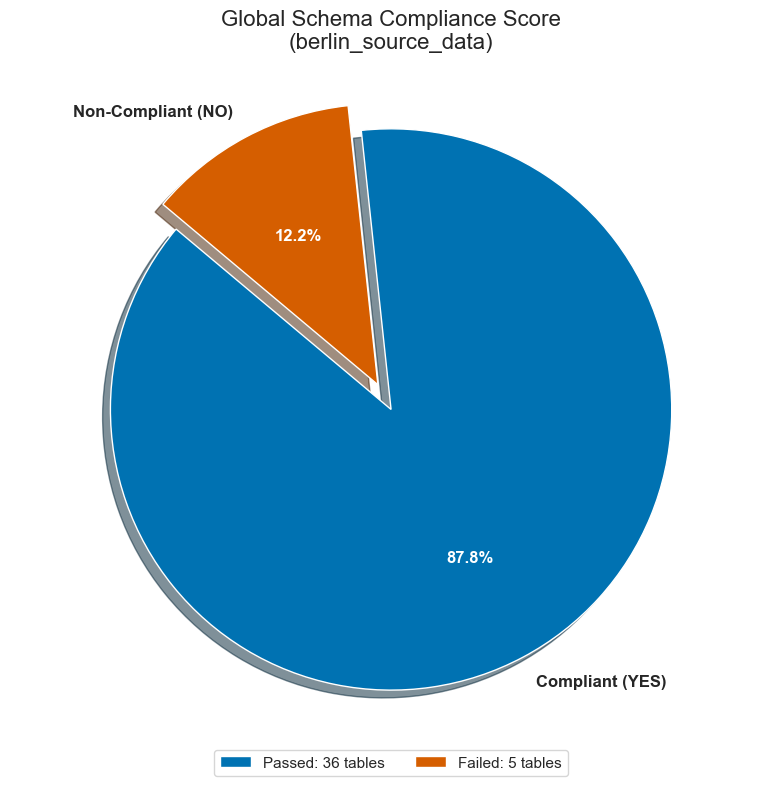

In [16]:
import matplotlib.pyplot as plt

# 1. Prepare the data
# Standardize the status to handle both "✅ YES" and "YES"
temp_status = df_report['Compliant'].astype(str).str.upper()
compliant_count = temp_status.str.contains('YES').sum()
non_compliant_count = temp_status.str.contains('NO').sum()

labels = ['Compliant (YES)', 'Non-Compliant (NO)']
sizes = [compliant_count, non_compliant_count]

# 2. Define Accessible Colors (Wong Palette)
# Blue (#0072B2) for YES, Orange (#D55E00) for NO
colors = ['#0072B2', '#D55E00']
explode = (0.1, 0)  # slightly "explode" the Compliant slice for emphasis

# 3. Create the Visualization
plt.figure(figsize=(8, 8))
patches, texts, autotexts = plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Style the percentage labels for readability
for autotext in autotexts:
    autotext.set_color('white')

plt.title('Global Schema Compliance Score\n(berlin_source_data)', fontsize=16, pad=20)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add a summary legend
plt.legend(
    labels=[f'Passed: {compliant_count} tables', f'Failed: {non_compliant_count} tables'], 
    loc="lower center", 
    bbox_to_anchor=(0.5, -0.1),
    ncol=2
)

plt.tight_layout()
plt.savefig('compliance_score_pie_chart.png')

Overall, 36 out of 41 tables (87.8%) are currently production-ready. The remaining tables are primarily flagged due to legacy geometry types or missing LOR columns, which are slated for remediation.